In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import scanpy as sc
import os
import re
from itertools import compress
import itertools
import random
import scipy.sparse
import time
import random
import time

sc.set_figure_params(dpi=80)

%config InlineBackend.figure_format='retina'

In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
copy_number_inference = lazy_import("copy_number_inference",os.path.join(utils_dir, "copy_number_inference.py"))

from general_utils import ismember, flatten_chain
from copy_number_inference import readGenomeAnnotation_mouse, getCopyNumberMatrix, fastClusterSmoothedCounts, plot_CNV_matrix


## Start CNV inference

In [ ]:
annotation_path = '../support/'
annotation_file = os.path.join(annotation_path, 'mm10_rmsk.gtf.gz')
genomeAnnotation = readGenomeAnnotation_mouse(annotation_file)

In [ ]:
adata = sc.read_h5ad('../data/Reyes_KPLOH_SUBSET_all__integrated.h5ad')

Use library size normalization

In [ ]:
adata_sub = adata.copy()
size_factors = np.exp(np.array(adata_sub.obs['log_lib_size_cellbender_noExcluded'].copy()))
adata_sub.X = np.array(adata_sub.layers['cellbender'].todense().copy())
adata_sub.X = adata_sub.X / np.array(size_factors)[:,None] * np.median(size_factors)


Identify a sample used as reference for CNV inference. Here, I chose a tumor DP sample, since it was the sample that had the most cells with diploid genomes.

In [ ]:
%%time
adata_sub.obs['sample_id'] = adata_sub.obs['replicate_id'].to_numpy()
adata_sub = adata_sub[np.argsort(adata_sub.obs['sample_id'], kind='mergesort')]

gene_ids = adata_sub.var_names
sample_ids = adata_sub.obs['sample_id']
reference_sample_id = 'B2_K5tumorDP_Spontaneous_tumor_p53_proficient_1.0_unhashed' # Define a particular sample to be used as reference
reference_cells = ismember(sample_ids, [reference_sample_id])[1]

# Get normalized count matrix as data frame, and import predefined blacklisted_genes
dataMatrix = pd.DataFrame(adata_sub.X, index = adata_sub.obs_names, columns = gene_ids) 
blacklisted_genes = pd.read_csv("../support/KPLOH_CNV_inference_blacklisted_genes.csv")['gene_id'].to_numpy()

# Parameters for CNV inference (min_threshold is min average expression threshold in reference cells,
# window size is the number of consecutive genes in the genome to consider for smoothing gene expression)
min_threshold = 0.01
window_size = 100

# Get smoothed count matrix
smoothed_counts, newAnnotation = getCopyNumberMatrix(
    dataMatrix, genomeAnnotation, gene_ids, sample_ids, 
    reference_cells, min_threshold, window_size, blacklisted_genes
)

Recentering medians
done
CPU times: user 50 s, sys: 9.05 s, total: 59 s
Wall time: 59.3 s


In [ ]:
# It is possible to cluster based on a subset of chromosomes
smoothed_counts, ordering = fastClusterSmoothedCounts(
    smoothed_counts, sample_ids, newAnnotation.loc[:,'chrNum'], list(range(1,21))
)
# Re-order dataset based on clustering results
adata_sub = adata_sub[ordering,:]

'B1_K5ctrl_Spontaneous_tumor_p53_deficient_4.0_unhashed'

'B1_K5ctrl_Spontaneous_tumor_p53_deficient_5.0_unhashed'

'B1_K5ctrl_Spontaneous_tumor_p53_deficient_6.0_unhashed'

'B1_K6ctrl_Spontaneous_met_p53_deficient_4.1_unhashed'

'B1_K6ctrl_Spontaneous_met_p53_deficient_4.2_unhashed'

...

'B7_K4pretumorSP_Spontaneous_pre-tumor_p53_deficient_4.0_A0302'

'B7_K4pretumorSP_Spontaneous_pre-tumor_p53_deficient_4.0_undefined'

'B8_K4microtumorSP_Spontaneous_pre-tumor_p53_deficient_5.0_unhashed'

'B8_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_5.0_unhashed'

'B8_K4pretumorSP_Spontaneous_pre-tumor_p53_deficient_5.0_unhashed'

Plot initial results

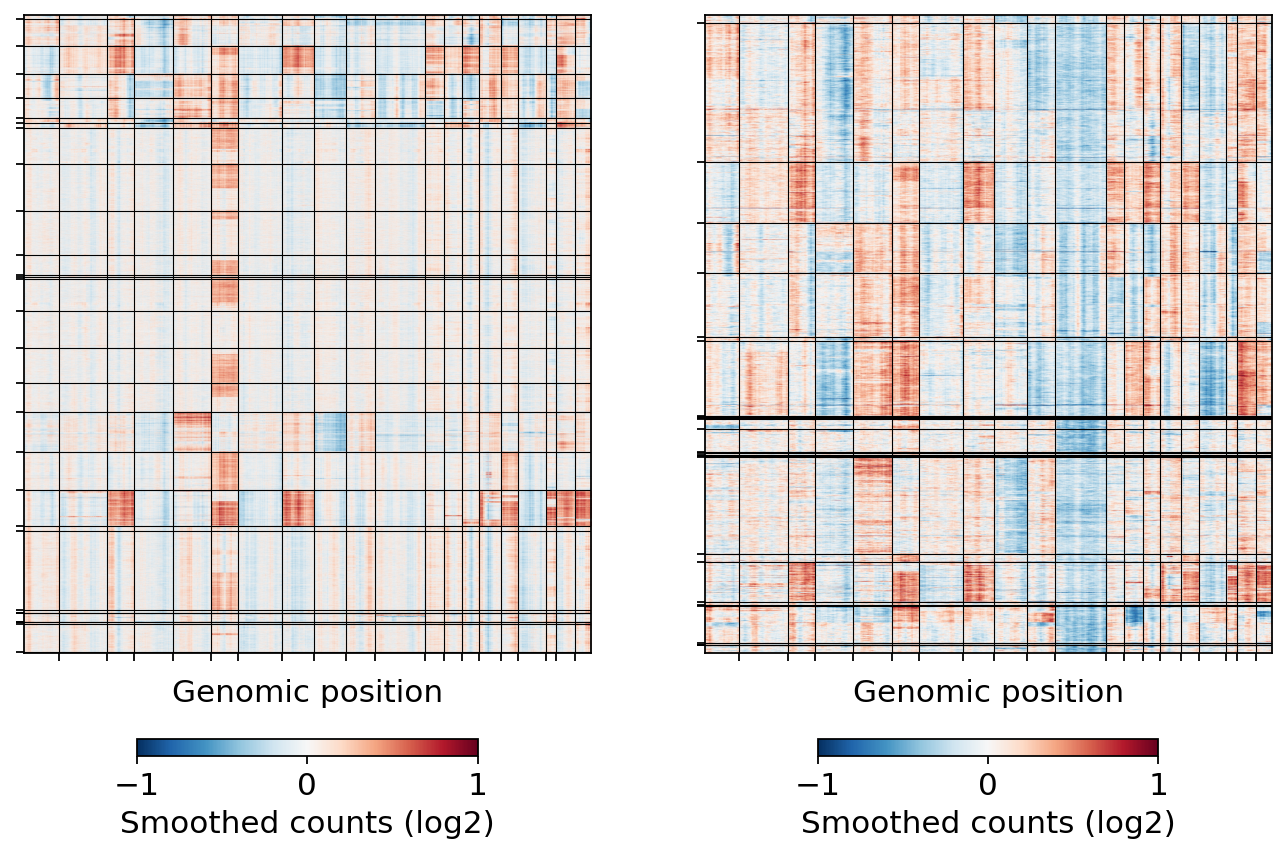

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, sharey=False, figsize=[10, 7])

selected_cells = np.array([True] * adata_sub.n_obs)
plot_CNV_matrix(smoothed_counts, adata_sub.obs['sample_id'], np.array(newAnnotation.loc[:,'chrNum']), selected_cells, ax1)

condition_filter = ismember(adata_sub.obs['condition'], np.unique(adata_sub.obs['condition']))[1] # Define selected conditions
cnv_filter = np.median(smoothed_counts[:,newAnnotation['chrNum'] == 11], axis=1) < -0.16
selected_cells = np.logical_and(condition_filter, cnv_filter)
plot_CNV_matrix(smoothed_counts, adata_sub.obs['sample_id'], np.array(newAnnotation.loc[:,'chrNum']), selected_cells, ax2)


After this first-pass CNV inference, I leverage the fact that samples largely come in pairs (p53 proficient and deficient) to refine CNV inference using sample-specific diploid cells. Since gain of chromosome 6 is recurrent in p53 proficient samples, I identify cells without this chromosome gain to use as reference.

(-1.0, 1.0)

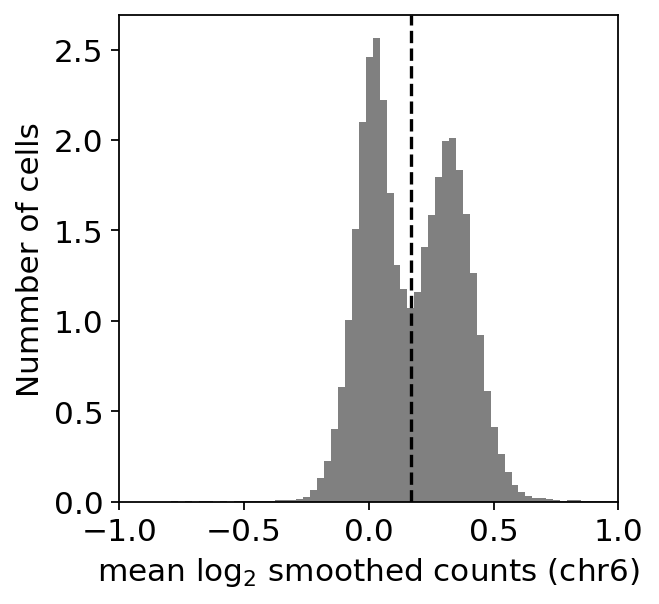

In [ ]:
# Go through a second round of CNV inference using sample-specific reference, after identifying diploid cells.
chr_6_mean = smoothed_counts[ismember(adata_sub.obs['condition'], np.unique(adata_sub.obs['condition']))[1],:]
chr_6_mean = chr_6_mean[:,newAnnotation['chrNum']==6].mean(axis=1)

f = plt.figure()
h = plt.hist(chr_6_mean, 100, color='gray', density = True)
plt.xlabel('mean log$_2$ smoothed counts (chr6)')
plt.grid(False)
plt.ylabel('Nummber of cells')
plt.axvline(x=0.17, linestyle = '--', color='black')
plt.xlim([-1,1])

Here, I identify groups of samples according to batch and replicate id. Unpaired samples (e.g., those from tumors from Burdziak, Alonso-Curbelo et al) are paired with replicate '0' of KPLOH samples.

In [ ]:
all_samples = np.array(np.unique(adata_sub.obs['sample_id']))
sample_pairing = []

for current_batch in [2,7,8]:
    batch_filter = np.array(ismember(adata_sub.obs['batch'], [current_batch])[1])
    for current_timepoint in ['pre-tumor', 'tumor']:
        condition_filter = np.array(ismember(adata_sub.obs['timepoint'], [current_timepoint])[1])
        pre_filter = (batch_filter) & (condition_filter)
        unique_replicates = np.unique(adata_sub.obs['replicate_number'][pre_filter])
        unique_replicates = unique_replicates[unique_replicates > 0]
        for i in unique_replicates:
            replicate_filter = np.array(ismember(adata_sub.obs['replicate_number'], [i])[1])
            group_filter = pre_filter & (replicate_filter)
            sample_pairing.append(list(np.unique(adata_sub.obs['sample_id'][group_filter])))
sample_pairing.append(list(all_samples[np.logical_not(ismember(all_samples, flatten_chain(sample_pairing))[1])]))
display(sample_pairing)

[['B2_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_1.0_unhashed',
  'B2_K4pretumorSP_Spontaneous_pre-tumor_p53_deficient_1.0_unhashed'],
 ['B2_K4microtumorSP_Spontaneous_pre-tumor_p53_deficient_2.0_unhashed',
  'B2_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_2.0_unhashed',
  'B2_K4pretumorSP_Spontaneous_pre-tumor_p53_deficient_2.0_unhashed'],
 ['B2_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_3.0_unhashed'],
 ['B2_K5tumorDP_Spontaneous_tumor_p53_proficient_1.0_unhashed',
  'B2_K5tumorSP_Spontaneous_tumor_p53_deficient_1.0_unhashed'],
 ['B2_K5tumorDP_Spontaneous_tumor_p53_proficient_2.0_unhashed',
  'B2_K5tumorSP_Spontaneous_tumor_p53_deficient_2.0_unhashed'],
 ['B2_K5tumorDP_Spontaneous_tumor_p53_proficient_3.0_unhashed',
  'B2_K5tumorSP_Spontaneous_tumor_p53_deficient_3.0_unhashed'],
 ['B7_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_4.0_A0301',
  'B7_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_4.0_A0302',
  'B7_K4pretumorDP_Spontaneous_pre-tumor_p53_profici

For each sample group, I identify cells that are p53 proficient, and that don't have chr6 amplification. I use this information to calculate mean expression per gene in the reference cells, and to exclude low expressed genes in any sample group

In [ ]:
chr_6_mean = smoothed_counts[:,newAnnotation['chrNum']==6].mean(axis=1)
adata_sub.obs['chr6_diploid'] = [x < 0.17 for x in chr_6_mean]
min_expression_threshold = 0.05
low_expressed_genes = [False] * adata.n_vars
for i in range(len(sample_pairing)):
    reference_samples = np.logical_and(ismember(adata_sub.obs['replicate_id'], sample_pairing[i])[1], adata_sub.obs['genotype'] == 'p53_proficient')
    mean_expression = adata.X[np.logical_and(reference_samples, adata_sub.obs['chr6_diploid']).to_numpy(),:].mean(axis=0)
    low_expressed_genes = np.logical_or(low_expressed_genes, mean_expression < min_expression_threshold)
low_expressed_genes = np.ravel(low_expressed_genes)

/tmp/ipykernel_3769588/3901771087.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['chr6_diploid'] = [x < 0.17 for x in chr_6_mean]


Next, I conduct paired CNV inference

In [ ]:
counts = pd.DataFrame(adata_sub.X, index = adata_sub.obs_names, columns=adata_sub.var_names)
counts = counts.loc[:,np.logical_not(low_expressed_genes)]
genomeAnnotation_filtered = genomeAnnotation.loc[ismember(genomeAnnotation['name2'], counts.columns)[1],:]

smoothed_counts_refined = adata_sub.X.copy()
for i in range(len(sample_pairing)):
    print(sample_pairing[i][0])
    subcells = np.where(ismember(adata_sub.obs['sample_id'], sample_pairing[i])[1])[0]
    current_sample_ids = adata_sub.obs['sample_id'].iloc[subcells]
    reference_samples = np.logical_and(ismember(adata_sub.obs['replicate_id'], sample_pairing[i])[1], adata_sub.obs['genotype'] == 'p53_proficient')
    reference_cells = np.logical_and(reference_samples, adata_sub.obs['chr6_diploid'])
    reference_cells = ismember(subcells, np.where(reference_cells)[0])[1]
    newSmoothed, newAnnotation2 = getCopyNumberMatrix(
        counts.iloc[subcells,:], 
        genomeAnnotation_filtered, 
        counts.columns, 
        current_sample_ids, 
        reference_cells, 
        min_threshold, 
        window_size, 
        blacklisted_genes
    )
    smoothed_counts_refined[subcells,0:newSmoothed.shape[1]] = newSmoothed

smoothed_counts_refined = smoothed_counts_refined[:,range(newAnnotation2.shape[0])]

adata_sub.obsm['smoothed_counts'] = smoothed_counts_refined
adata_sub.uns['newAnnotation'] = newAnnotation2


B2_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_1.0_unhashed
Recentering medians
done
B2_K4microtumorSP_Spontaneous_pre-tumor_p53_deficient_2.0_unhashed
Recentering medians
done
B2_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_3.0_unhashed
Recentering medians
done
B2_K5tumorDP_Spontaneous_tumor_p53_proficient_1.0_unhashed
Recentering medians
done
B2_K5tumorDP_Spontaneous_tumor_p53_proficient_2.0_unhashed
Recentering medians
done
B2_K5tumorDP_Spontaneous_tumor_p53_proficient_3.0_unhashed
Recentering medians
done
B7_K4pretumorDP_Spontaneous_pre-tumor_p53_proficient_4.0_A0301
Recentering medians
done
B8_K4microtumorSP_Spontaneous_pre-tumor_p53_deficient_5.0_unhashed
Recentering medians
done
B1_K5ctrl_Spontaneous_tumor_p53_deficient_4.0_unhashed
Recentering medians
done


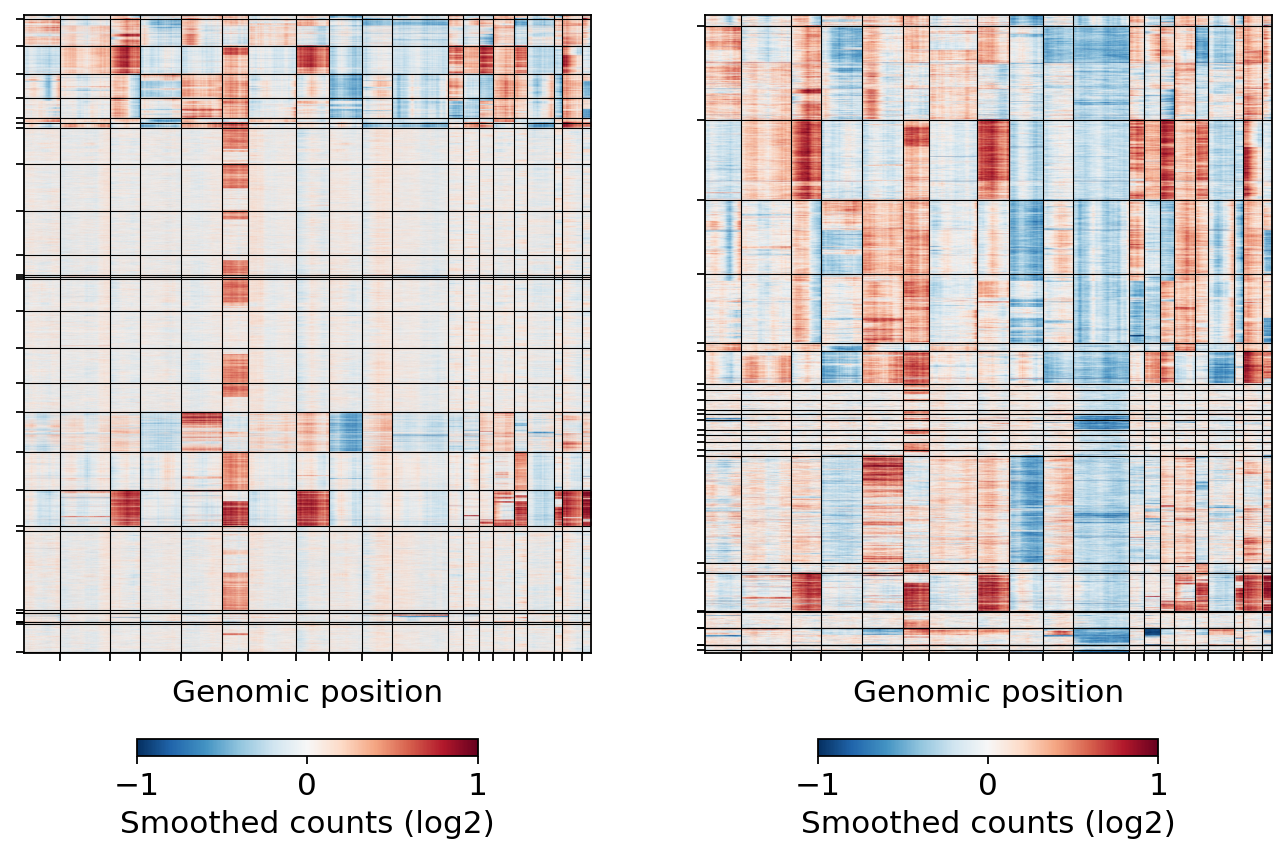

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, sharey=False, figsize=[10, 7])

selected_cells = np.array([True] * adata_sub.n_obs)
plot_CNV_matrix(
    adata_sub.obsm['smoothed_counts'], 
    adata_sub.obs['sample_id'], 
    np.array(adata_sub.uns['newAnnotation'].loc[:,'chrNum']), 
    selected_cells, ax1
)

condition_filter = ismember(adata_sub.obs['condition'], np.unique(adata_sub.obs['condition']))[1] # Define selected conditions
cnv_filter = np.median(adata_sub.obsm['smoothed_counts'][:,adata_sub.uns['newAnnotation']['chrNum'] == 11], axis=1) < -0.16
selected_cells = np.logical_and(condition_filter, cnv_filter)
plot_CNV_matrix(
    adata_sub.obsm['smoothed_counts'], 
    adata_sub.obs['sample_id'], 
    np.array(adata_sub.uns['newAnnotation'].loc[:,'chrNum']), 
    selected_cells, ax2
)


Average smoothed chromosome expression to identify estimate the number of karyotype changes per single cell

In [ ]:
newAnnotation = adata_sub.uns['newAnnotation']
smoothed_counts = adata_sub.obsm['smoothed_counts']
unique_chr = np.unique(newAnnotation['chrNum'])

chrom_average = []
for chrom in unique_chr:
    chrom_average.append(np.ravel(np.median(smoothed_counts[:,newAnnotation['chrNum'] == chrom], axis=1)))
chrom_average = pd.DataFrame(chrom_average).T
chrom_average.index = adata_sub.obs_names

karyotype_change = np.abs(chrom_average) > 0.16
numChanges = np.array(karyotype_change.sum(axis=1)) - np.array([int(x) for x in karyotype_change.iloc[:,10]])

adata_sub.obsm['chrom_change'] = chrom_average.to_numpy()

Classify cells based on their degree of karyotype changes

In [ ]:
karyotype_class = np.array(['1_pre_dp_diploid'] * adata_sub.n_obs, dtype='object')
karyotype_class[chrom_average.iloc[:,5] > 0.16] = '2_pre_dp_chr6_gain'
karyotype_class[np.logical_and(numChanges < 9, ismember(adata_sub.obs['condition'], ['K4pretumorSP', 'K4microtumorSP'])[1])] = '3_pre_sp_quiet'
karyotype_class[np.logical_and(numChanges >= 9, ismember(adata_sub.obs['condition'], ['K4pretumorSP', 'K4microtumorSP'])[1])] = '4_pre_sp_rearranged'

batch_filter = ismember(adata_sub.obs['batch'], [2,8])[1]
condition_filter = ismember(adata_sub.obs['condition'], ['K4microtumorSP'])[1]
karyotype_class[np.logical_and(batch_filter, condition_filter)] = '4_pre_sp_rearranged'

karyotype_class[ismember(adata_sub.obs['condition'], ['K5tumorSP', 'K5ctrl', 'K6ctrl'])[1]] = '6_tumor_sp'

adata_sub.obs['karyotype_class'] = karyotype_class

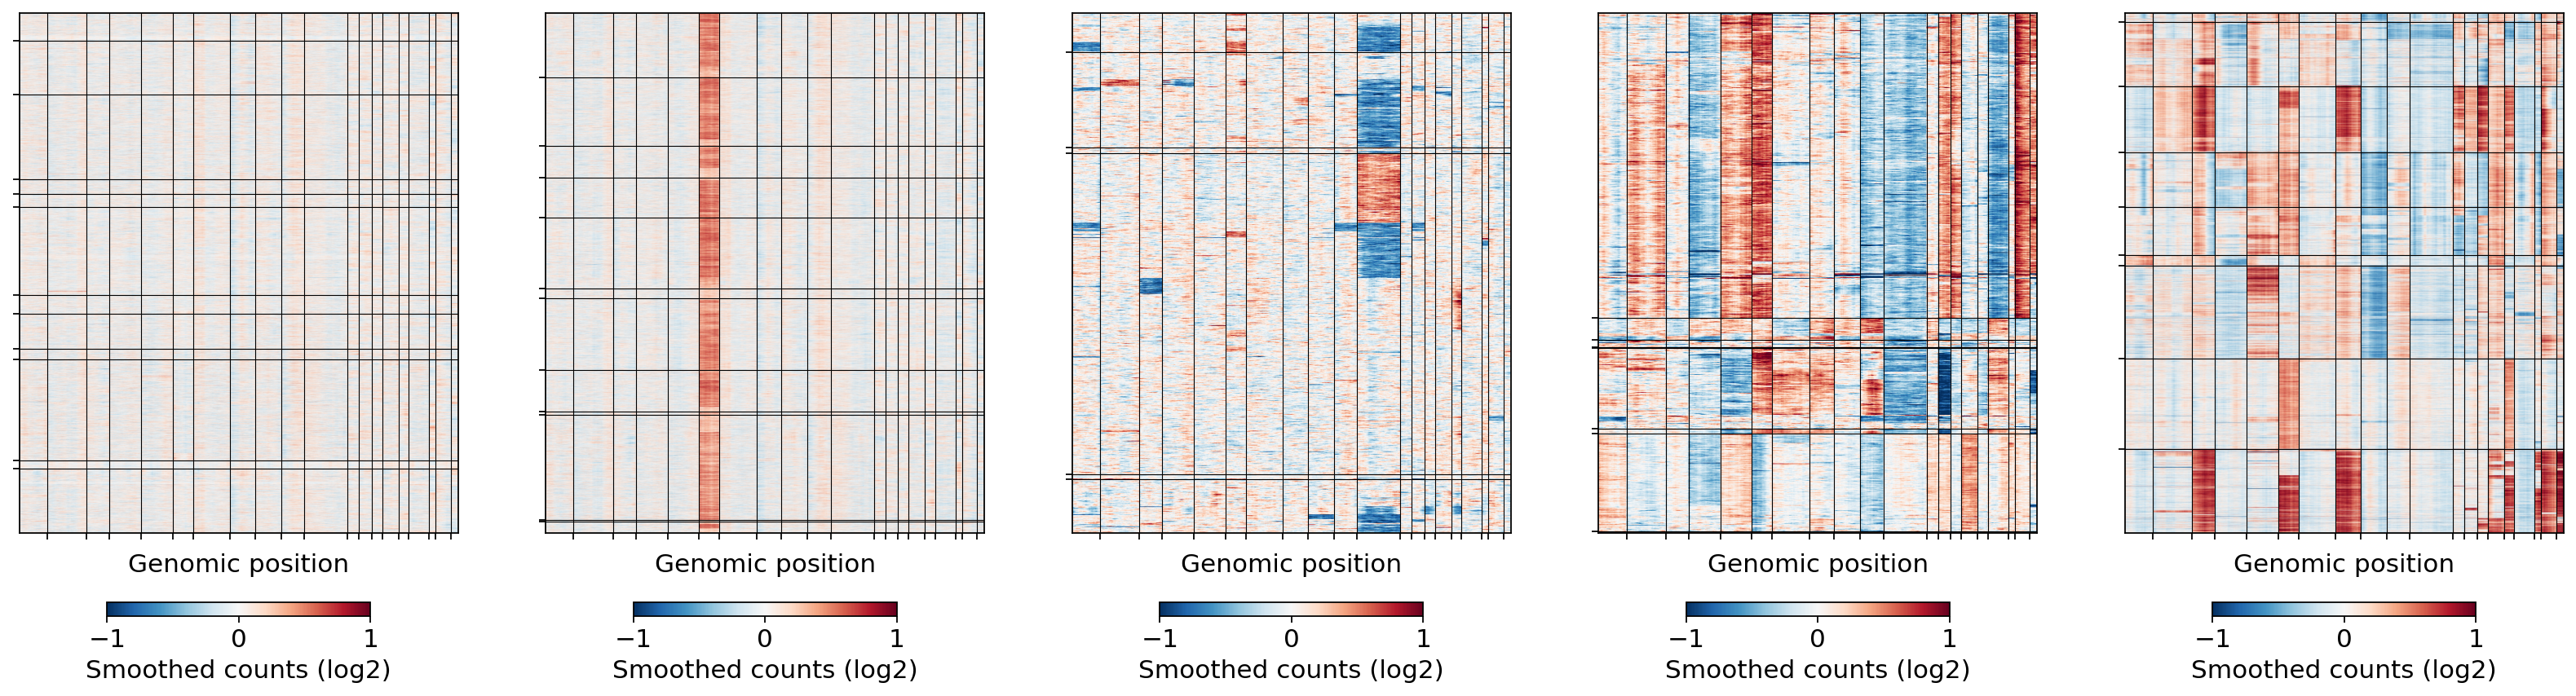

In [ ]:
f, ax = plt.subplots(1,5, figsize=[25,7])
plot_CNV_matrix(adata_sub.obsm['smoothed_counts'], adata_sub.obs['sample_id'], adata_sub.uns['newAnnotation']['chrNum'].to_numpy(), adata_sub.obs['karyotype_class'] == '1_pre_dp_diploid', ax[0])
plot_CNV_matrix(adata_sub.obsm['smoothed_counts'], adata_sub.obs['sample_id'], adata_sub.uns['newAnnotation']['chrNum'].to_numpy(), adata_sub.obs['karyotype_class'] == '2_pre_dp_chr6_gain', ax[1])
plot_CNV_matrix(adata_sub.obsm['smoothed_counts'], adata_sub.obs['sample_id'], adata_sub.uns['newAnnotation']['chrNum'].to_numpy(), adata_sub.obs['karyotype_class'] == '3_pre_sp_quiet', ax[2])
plot_CNV_matrix(adata_sub.obsm['smoothed_counts'], adata_sub.obs['sample_id'], adata_sub.uns['newAnnotation']['chrNum'].to_numpy(), adata_sub.obs['karyotype_class'] == '4_pre_sp_rearranged', ax[3])
plot_CNV_matrix(adata_sub.obsm['smoothed_counts'], adata_sub.obs['sample_id'], adata_sub.uns['newAnnotation']['chrNum'].to_numpy(), adata_sub.obs['karyotype_class'] == '6_tumor_sp', ax[4])


Save preprocessed CNV inference matrix

In [ ]:
adata_sub.X = scipy.sparse.csr_matrix(adata_sub.X)

In [ ]:
output_file = '../data/Reyes_KPLOH_SUBSET_all__CNV.h5ad'
sc.write(filename = output_file, adata = adata_sub)